In [4]:
from tomo_calc import *
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def fidelity(rho, psi):
    val = np.real(psi.conj().T @ rho @ psi)
    return float(np.clip(val, 0.0, 1.0))

# Для одного состояния

In [5]:
num_of_samples = np.logspace(1, 10, 10, dtype=int)
infid_pinv_lsq = []
infid_cvx = []

np.random.seed(42)
dim = 2**2
psi = np.random.randn(dim) + 1j * np.random.randn(dim)
psi /= np.linalg.norm(psi)

cond_number = []

for N in num_of_samples:
    M_dag, f = get_freq_M(psi, N=N)
    cond_number.append(np.linalg.cond(M_dag))
    rho_pinv = pseudo_inverse_method(M_dag, f)

    rho_pinv_lsq = lsq_improvement(rho_pinv)
    infid_pinv_lsq.append(max(1 - fidelity(rho_pinv_lsq, psi), 1e-15))

    rho_cvx = cvx_method(M_dag, f)
    infid_cvx.append(max(1 - fidelity(rho_cvx, psi), 1e-15))

print(f'Число обусловленностей: {np.mean(cond_number)} +- {np.std(cond_number)}')

Число обусловленностей: 3.000000000000001 +- 0.0


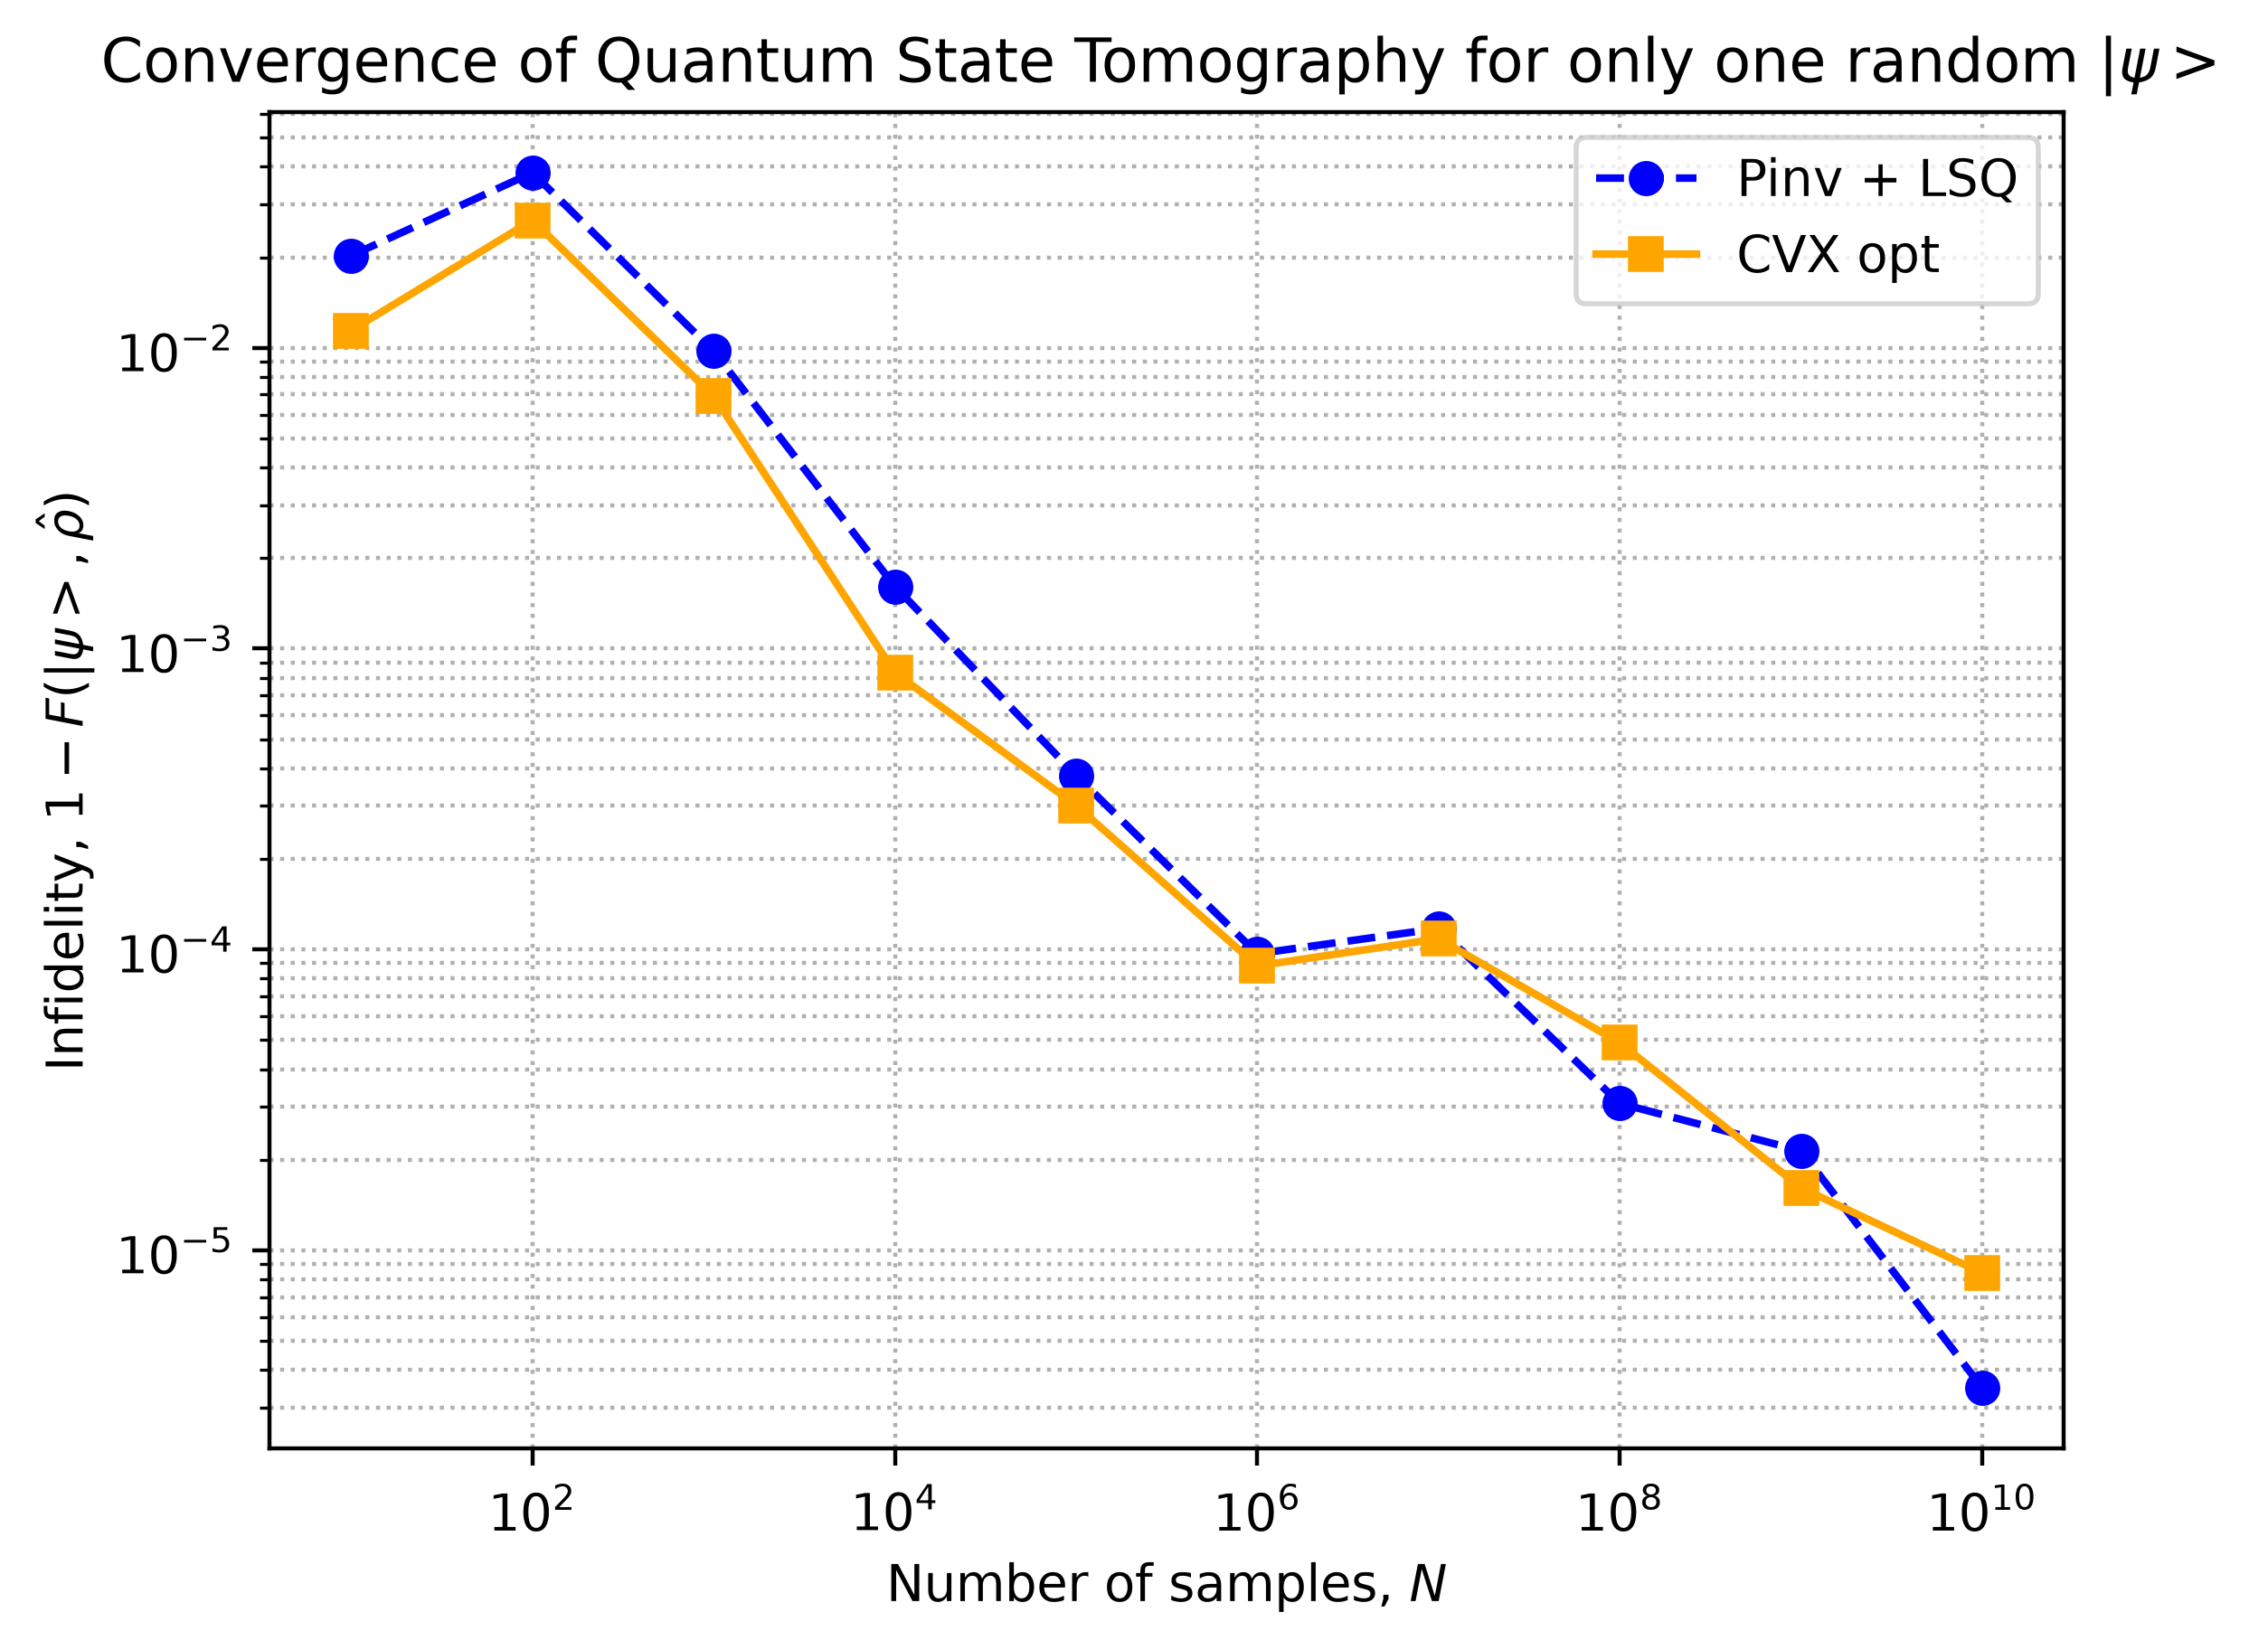

In [6]:
plt.figure(dpi=400)
plt.loglog(num_of_samples, infid_pinv_lsq, 'o--', label=r'Pinv + LSQ', color='blue')
plt.loglog(num_of_samples, infid_cvx, 's-', label=r'CVX opt', color='orange')

plt.xlabel(r'Number of samples, $N$')
plt.ylabel(r'Infidelity, $1-F(|\psi>, \hat{\rho})$')
plt.legend()
plt.grid(True, which="both", ls=":")

plt.title(r'Convergence of Quantum State Tomography for only one random $|\psi>$')
plt.show()

# Для 1000 состояний

In [7]:
np.random.seed(42)
dim = 2**2
num_states = 1000
fixed_states = []

for _ in range(num_states):
    psi = np.random.randn(dim) + 1j * np.random.randn(dim)
    psi /= np.linalg.norm(psi)
    fixed_states.append(psi)

num_of_samples = np.logspace(2, 6, 5, dtype=int) 

mean_infid_pinv_lsq = []
mean_infid_cvx = []
cond_numbers = []

# 3. Основной цикл
for N in num_of_samples:
    infid_pinv_lsq_list = []
    infid_cvx_list = []
    cn = []
    
    # tqdm отобразит ползунок выполнения для текущего N
    for psi in tqdm(fixed_states, desc=f"Расчет для N={N}"):
        
        M_dag, f = get_freq_M(psi, N=N)
        cn.append(np.linalg.cond(M_dag))
        # Pinv
        rho_pinv = pseudo_inverse_method(M_dag, f)

        # Pinv + lsq
        rho_pinv_lsq = lsq_improvement(rho_pinv)
        infid_pinv_lsq_list.append(max(1.0 - fidelity(rho_pinv_lsq, psi), 1e-15))
        
        # CVX
        rho_cvx = cvx_method(M_dag, f)
        infid_cvx_list.append(max(1.0 - fidelity(rho_cvx, psi), 1e-15))

    # Усредняем неверность по всем 1000 состояниям
    cond_numbers.append(np.mean(cn))
    mean_infid_pinv_lsq.append(np.mean(infid_pinv_lsq_list))
    mean_infid_cvx.append(np.mean(infid_cvx_list))

print("Числа обусловленностей:", cond_numbers)

Расчет для N=100:   0%|          | 0/1000 [00:00<?, ?it/s]

Расчет для N=1000:   0%|          | 0/1000 [00:00<?, ?it/s]

Расчет для N=10000:   0%|          | 0/1000 [00:00<?, ?it/s]

Расчет для N=100000:   0%|          | 0/1000 [00:00<?, ?it/s]

Расчет для N=1000000:   0%|          | 0/1000 [00:00<?, ?it/s]

Числа обусловленностей: [np.float64(3.0000000000000004), np.float64(3.0000000000000004), np.float64(3.0000000000000004), np.float64(3.0000000000000004), np.float64(3.0000000000000004)]


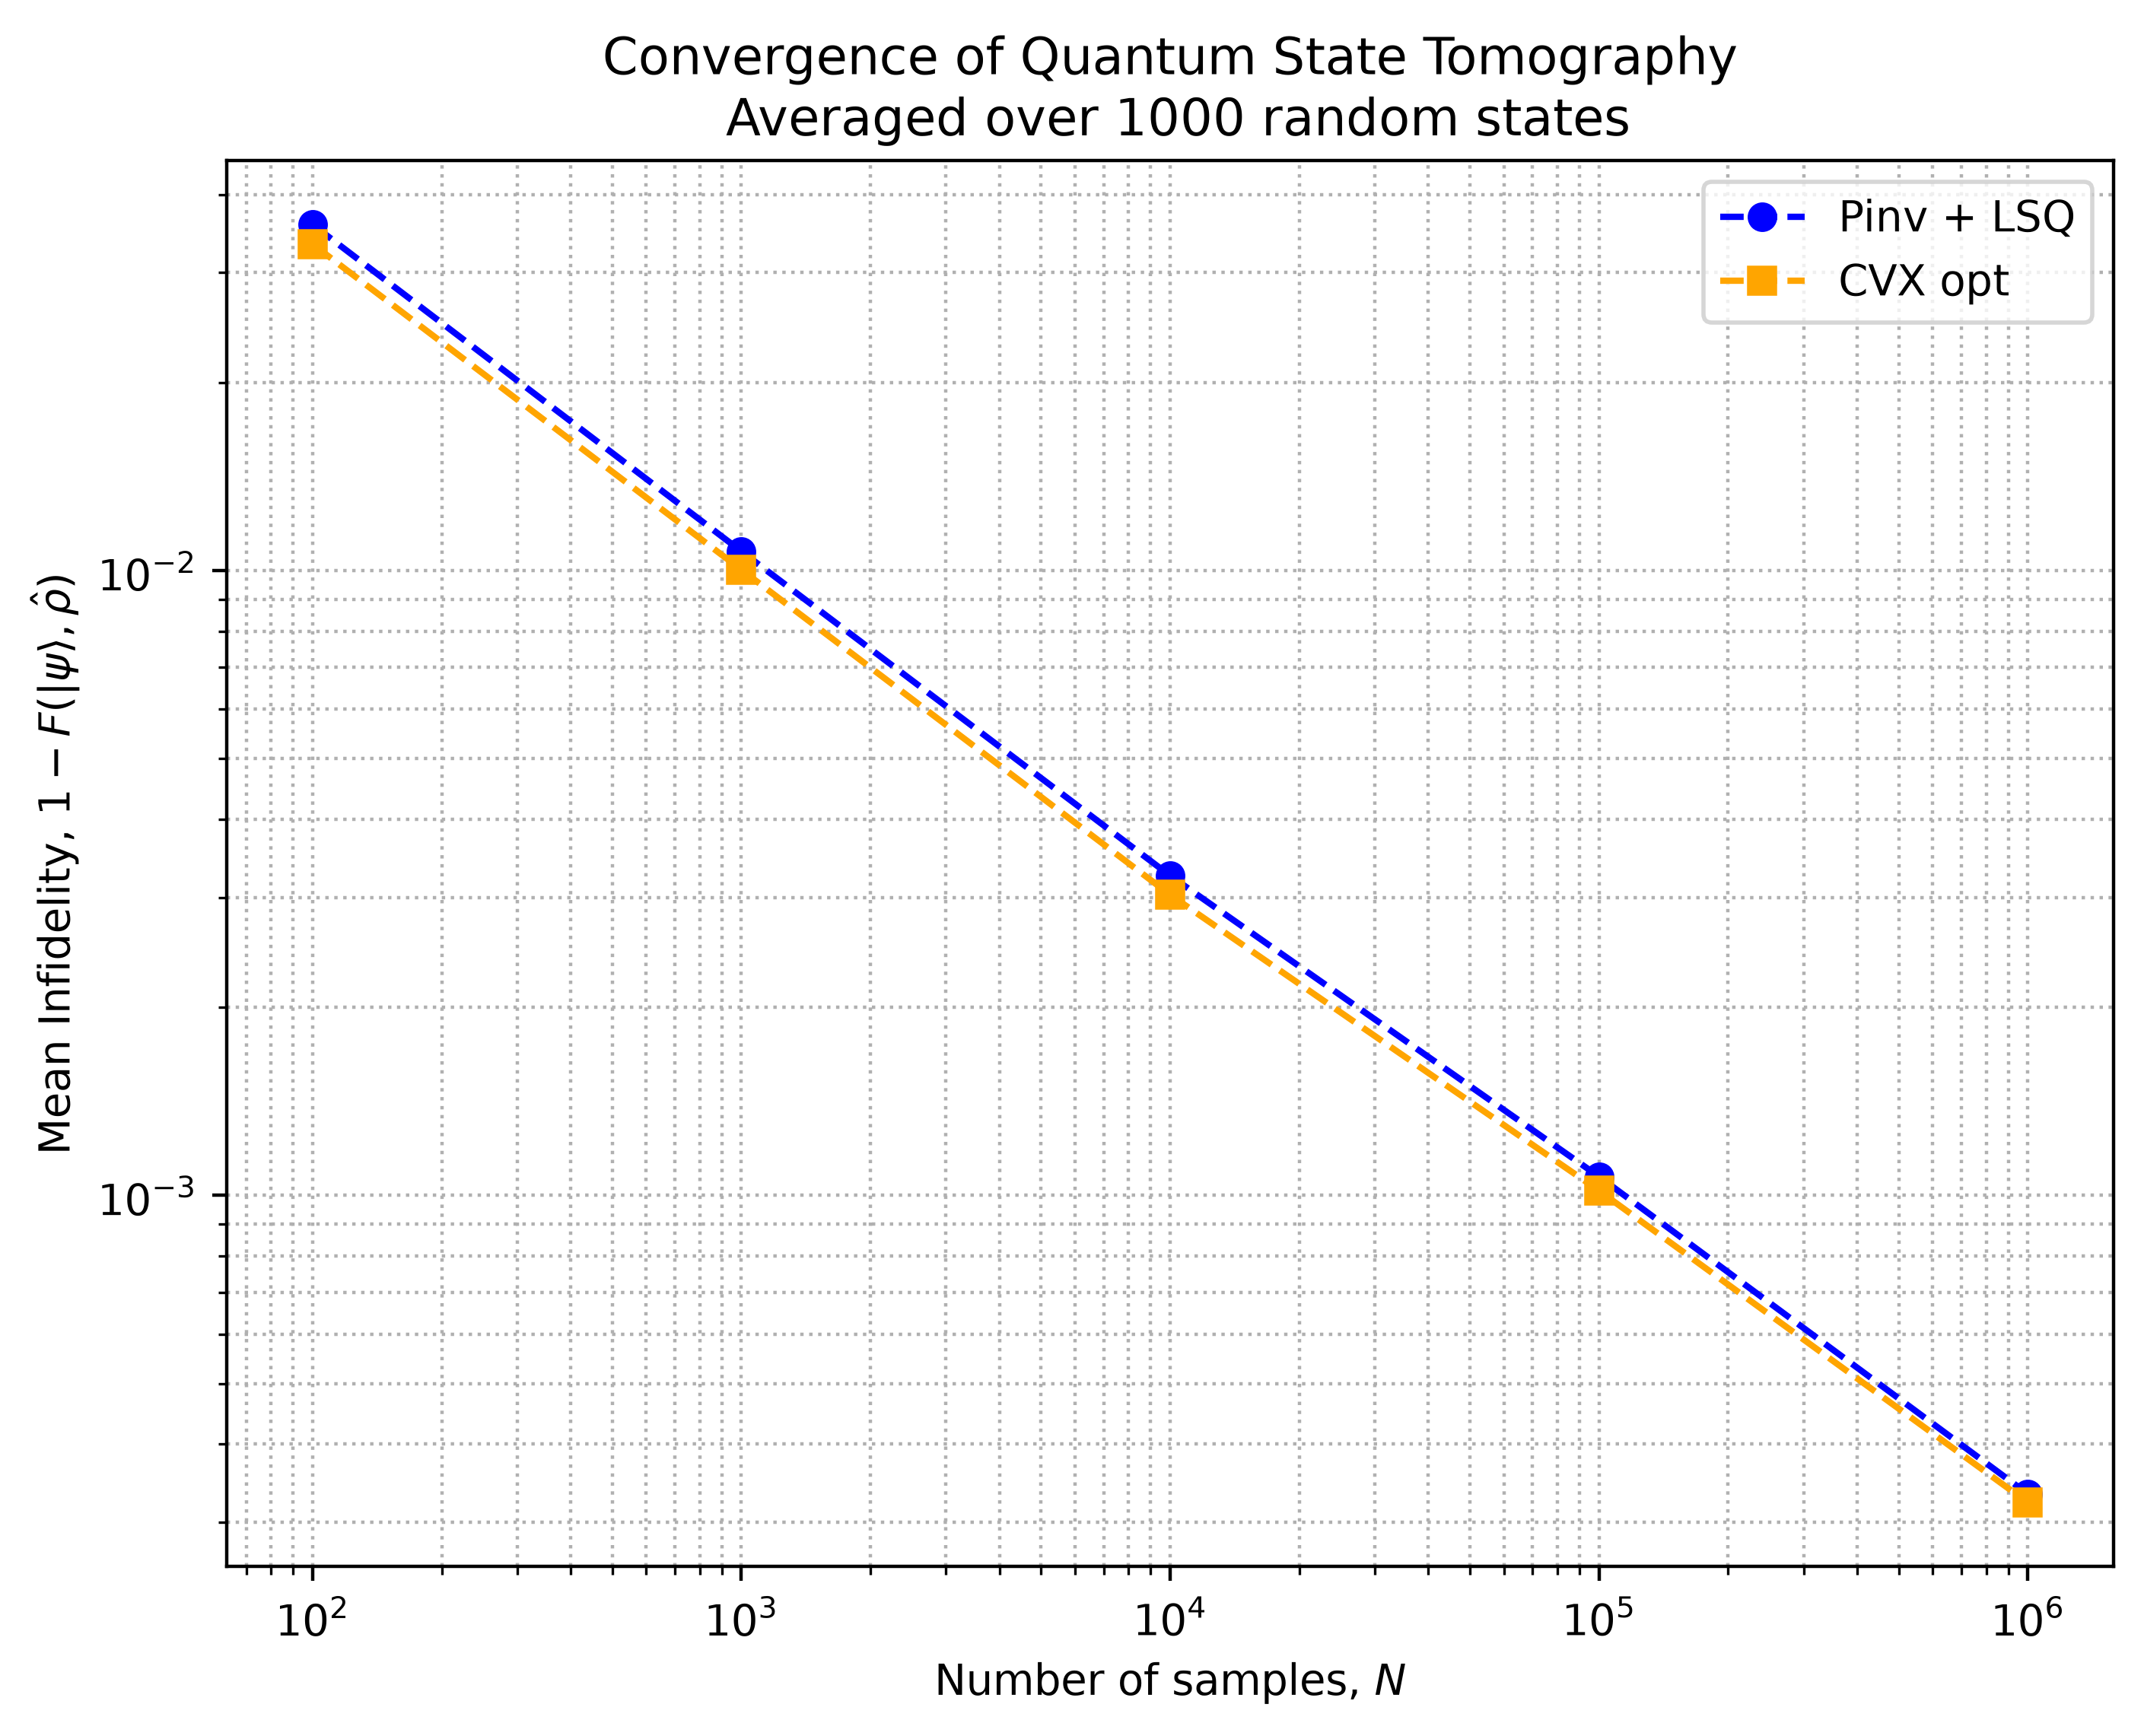

Показатель сходимости q (PINV + LSQ): 0.51
Показатель сходимости q (CVX): 0.50


In [8]:
plt.figure(figsize=(8, 6), dpi=400)

plt.loglog(num_of_samples, mean_infid_pinv_lsq, 'o--', label=r'Pinv + LSQ', color='blue')
plt.loglog(num_of_samples, mean_infid_cvx, 's--', label=r'CVX opt', color='orange')

plt.xlabel(r'Number of samples, $N$')
plt.ylabel(r'Mean Infidelity, $1-F(|\psi\rangle, \hat{\rho})$')
plt.legend()
plt.grid(True, which="both", ls=":")
plt.title(f'Convergence of Quantum State Tomography\n Averaged over {num_states} random states')

plt.show()

# Оценка наклона сходимости для усредненных данных
q_lsq, _ = np.polyfit(np.log(num_of_samples), np.log(mean_infid_pinv_lsq), 1)
q_cvx, _ = np.polyfit(np.log(num_of_samples), np.log(mean_infid_cvx), 1)
print(f"Показатель сходимости q (PINV + LSQ): {-q_lsq:.2f}")
print(f"Показатель сходимости q (CVX): {-q_cvx:.2f}")